In [ ]:
!pip install preliz==0.19.0

In [ ]:
!pip install pymc==5.23.0

In [ ]:
!pip install numpy==1.26.4

In [1]:
import warnings

warnings.filterwarnings('ignore')

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
import pandas as pd
import pymc as pm
import preliz as pz
from scipy import stats as sps
import pytensor
import pytensor.tensor as pt
from scipy.stats import nbinom

from plotly.subplots import make_subplots

In [7]:
df = pd.read_csv('/content/drive/MyDrive/WHO-COVID-19-global-daily-data.csv')

Модель представляет собой упрощенную версию rt-live.

В модели используется генерация количества заболеваний в первый день (seed), R_t и alpha.

Число заболеваний в первый день = seed (Априорное распределение Exponential, взято из модели rt-live), r_t моделируется при помощи случайного гауссовского блуждания, sigma зафиксирована.

Количество инфекций (mu для NegativeBinomial) рассчитывается при помощи произведения R_t и свертки над generation time и числом инфекций в прошедшие дни.

Функция правдоподобия: NegativeBinomial(mu, alpha)

In [5]:
class CovidModel():
    def __init__(self, country):
        # гиперпараметры сэмплирования
        self.draws = 100
        self.tune = 200
        self.chains = 4
        self.cores = 4
        self.target_accept = 0.95
        self.random_seed = 42

        self.holdout_days = 13 # с 02.12.2020 данные используем для тестирования

        # выделяю страну и подготавливаю данные
        data = df[
            (df['Country'] == country) & \
            (df['Date_reported'] <= '2020-12-14') & \
            ((df['New_cases'] >= 100))
            ][['Date_reported', 'New_cases']].reset_index(drop=True)

        data['days_since_100'] = (pd.to_datetime(data['Date_reported']) - pd.to_datetime(data['Date_reported'].min())).dt.days

        # заполняю пропуски предыдущим значением
        full_dates = pd.date_range(data["Date_reported"].min(), data["Date_reported"].max())
        df_full = pd.DataFrame({"Date_reported": full_dates}).astype(str)
        data = df_full.merge(data, on="Date_reported", how="left")
        for i in range(1, len(data)):
            if pd.isna(data.loc[i, "New_cases"]):
                data.loc[i, "New_cases"] = data.loc[i-1, "New_cases"]
                data.loc[i, "days_since_100"] = data.loc[i-1, "days_since_100"] + 1

        self.data = data
        self.day_t = data["days_since_100"].to_numpy().flatten()
        self.confirmed = data["New_cases"].to_numpy().flatten()

        self.train_confirmed = self.confirmed[:-self.holdout_days]
        self.test_confirmed = self.confirmed[-self.holdout_days:]
        self.train_days = self.day_t[:-self.holdout_days]
        self.test_days = self.day_t[-self.holdout_days:]

    def generate_convolution_ready_gt(self, len_observed):
        # генерирую значения функции для generation time
        # генерация взята из модели rt-live
        # сама функция generation time была опубликована здесь:
        # https://www.ijidonline.com/article/S1201-9712(20)30119-3/pdf

        mean_si = 4.7
        std_si = 2.9
        mu_si = np.log(mean_si ** 2 / np.sqrt(std_si ** 2 + mean_si ** 2))
        sigma_si = np.sqrt(np.log(std_si ** 2 / mean_si ** 2 + 1))
        dist = sps.lognorm(scale=np.exp(mu_si), s=sigma_si)

        g_range = np.arange(0, 20)
        gt = pd.Series(dist.cdf(g_range), index=g_range)
        gt = gt.diff().fillna(0)
        gt /= gt.sum()
        gt = gt.values

        convolution_ready_gt = np.zeros((len_observed - 1, len_observed))
        for t in range(1, len_observed):
            begin = np.maximum(0, t - len(gt) + 1)
            slice_update = gt[1 : t - begin + 1][::-1]
            convolution_ready_gt[
                t - 1, begin : begin + len(slice_update)
            ] = slice_update

        return convolution_ready_gt

    def sample(self):
        with pm.Model() as self.model:
            day = pm.Data("day", self.train_days)
            confirmed_data = pm.Data("confirmed_data", self.train_confirmed)
            convolution_gt = pm.Data("convolution_gt", self.generate_convolution_ready_gt(day.get_value().shape[0]))

            log_r_t = pm.GaussianRandomWalk(
                "log_r_t",
                sigma=0.035,
                steps=day.get_value().shape[0]-1
            )

            r_t = pm.Deterministic("r_t", pm.math.exp(log_r_t))

            seed = pm.Exponential("seed", 1 / 0.02)
            y0 = pt.zeros(day.get_value().shape[0])
            y0 = pt.set_subtensor(y0[0], seed)
            outputs, _ = pytensor.scan(
                fn=lambda t, gt, y, r_t: pt.set_subtensor(y[t], pt.sum(r_t * y * gt)),
                sequences=[pt.arange(1, day.get_value().shape[0]), convolution_gt],
                outputs_info=y0,
                non_sequences=r_t,
                n_steps=day.get_value().shape[0] - 1,
            )
            infections = pm.Deterministic("infections", outputs[-1])

            pm.NegativeBinomial(
                "obs",
                mu=infections,
                alpha=pm.Gamma("alpha", mu=6, sigma=1),
                observed=confirmed_data
            )

            self.trace = pm.sample(
                draws=self.draws,
                tune=self.tune,
                chains=self.chains,
                cores=self.cores,
                target_accept=self.target_accept,
                random_seed=self.random_seed,
                return_inferencedata=True
            )

    def trace_summary(self):
        # оцениваем трейсы параметров в результате процедуры
        az.plot_trace(self.trace, var_names=["alpha", "seed"])
        return az.summary(self.trace, var_names=["r_t", "seed", "alpha"])

    def plot_rt(self):
        # отрисовываем r_t по дням
        r_t_samples = self.trace.posterior["r_t"]
        r_t_mean = r_t_samples.mean(dim=("chain", "draw"))
        r_t_hdi = az.hdi(self.trace, var_names=["r_t"], hdi_prob=0.95)

        plt.figure(figsize=(12,5))
        plt.plot(self.train_days, r_t_mean, color="blue", label="R_t mean")
        plt.fill_between(
            self.train_days,
            r_t_hdi.r_t[:,0],
            r_t_hdi.r_t[:,1],
            color="blue",
            alpha=0.3,
            label="95% CI"
        )
        plt.xlabel("Day")
        plt.ylabel("R_t")
        plt.legend()
        plt.show()

    def plot_posterior_predictive(self):
        # оцениваем модель на тренировочной выборке
        with self.model:
            post_pred = pm.sample_posterior_predictive(self.trace.posterior, random_seed=self.random_seed)

        post_pred_samples = post_pred.posterior_predictive["obs"].sel(chain=0).values.squeeze().T
        dates = pd.to_datetime(self.data['Date_reported']).dt.date[:-self.holdout_days]
        fig, ax = plt.subplots(figsize=(10, 6))

        for i in range(min(100, post_pred_samples.shape[1])):
            ax.plot(
                dates,
                post_pred_samples[:, i],
                color="steelblue",
                linewidth=0.5,
                alpha=0.4,
            )

        ax.plot(
            dates,
            self.train_confirmed,
            color="red",
            linewidth=2,
            marker="o",
            label="Data",
        )


        ax.set_yscale("log")
        ax.set_xlabel("Date")
        ax.set_ylabel("Заболеваемость (log шкала)")
        ax.set_title("Posterior predictive samples vs data")
        ax.legend()
        ax.grid(True, which="both", linestyle="--", alpha=0.5)

        plt.tight_layout()
        plt.show()

        self.post_pred_samples = post_pred_samples

    def plot_holdout(self):
        # делаем предсказание на новый период
        posterior_rt = self.trace.posterior['log_r_t'].values
        posterior_seed = self.trace.posterior['seed'].values
        posterior_alpha = self.trace.posterior['alpha'].values
        n_future = self.holdout_days

        convolution_ready_gt = self.generate_convolution_ready_gt(len(self.confirmed))

        sigma_rw = 0.035

        def extend_rt(rt_series, n_future, sigma):
            rt_future = [rt_series[-1]]
            for _ in range(n_future - 1):
                rt_future.append(rt_future[-1] + np.random.normal(0, sigma))
            return np.array(rt_future)

        extended_rt = np.exp(np.array([
            np.concatenate([r, extend_rt(r, n_future, sigma_rw)])
            for r in posterior_rt.reshape(-1, posterior_rt.shape[-1])
        ]))

        def simulate_infections(rt, gt, seed):
            infections = np.zeros(len(rt) + 1)
            infections[0] = seed
            for t in range(1, len(infections)):
                begin = max(0, t - len(gt) + 1)
                window = gt[1 : t - begin + 1][::-1]
                infections[t] = np.sum(rt[begin:t] * infections[begin:t] * window)
            return infections

        future_infections = np.array([
            simulate_infections(rt_series, gt, seed)
            for rt_series, seed in zip(extended_rt, posterior_seed.flatten())
        ])

        future_obs = np.zeros((future_infections.shape[0], n_future))

        for i in range(future_infections.shape[0]):
            mu = future_infections[i, -n_future:]
            alpha = posterior_alpha.flatten()[i % len(posterior_alpha.flatten())]
            p = alpha / (alpha + mu)
            future_obs[i] = nbinom.rvs(alpha, p)

        mean_forecast = np.mean(future_obs, axis=0)
        mean_forecast_train = np.mean(self.post_pred_samples.T, axis=0)

        dates = pd.to_datetime(self.data['Date_reported']).dt.date

        plt.figure(figsize=(10,5))
        plt.plot(pd.to_datetime(dates).dt.date, self.confirmed, label="Фактическая заболеваемость")

        plt.plot(
            pd.to_datetime(dates).dt.date.iloc[:-13],
            mean_forecast_train, label="Предсказание на обучающей выборке", color="orange"
        )

        plt.plot(
            pd.to_datetime(dates).dt.date.iloc[-13:],
            mean_forecast, label="Предсказание на hold-out", color="red"
        )

        plt.legend()
        plt.show()



In [30]:
# не сохранил gt внутри класса, поэтому вынес в код, чтобы не перезапускать модели

mean_si = 4.7
std_si = 2.9
mu_si = np.log(mean_si ** 2 / np.sqrt(std_si ** 2 + mean_si ** 2))
sigma_si = np.sqrt(np.log(std_si ** 2 / mean_si ** 2 + 1))
dist = sps.lognorm(scale=np.exp(mu_si), s=sigma_si)

g_range = np.arange(0, 20)
gt = pd.Series(dist.cdf(g_range), index=g_range)
gt = gt.diff().fillna(0)
gt /= gt.sum()
gt = gt.values

In [ ]:
model = CovidModel('Russian Federation')

In [ ]:
model.sample()

Output()

ERROR:pymc.stats.convergence:The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
r_t[0],17.788,1.240,15.515,20.132,0.049,0.043,660.0,435.0,0.99
r_t[1],15.177,0.971,13.509,17.182,0.041,0.040,546.0,417.0,1.01
r_t[2],12.905,0.788,11.602,14.582,0.031,0.029,601.0,456.0,1.01
r_t[3],10.953,0.641,9.882,12.230,0.031,0.026,444.0,329.0,1.00
r_t[4],9.369,0.549,8.362,10.364,0.028,0.024,393.0,391.0,1.00
...,...,...,...,...,...,...,...,...,...
r_t[251],1.083,0.155,0.790,1.331,0.008,0.007,350.0,310.0,1.01
r_t[252],1.080,0.156,0.792,1.343,0.008,0.007,365.0,310.0,1.01
r_t[253],1.080,0.160,0.788,1.363,0.008,0.007,383.0,337.0,1.01
seed,3.323,0.268,2.796,3.773,0.015,0.010,319.0,413.0,1.02


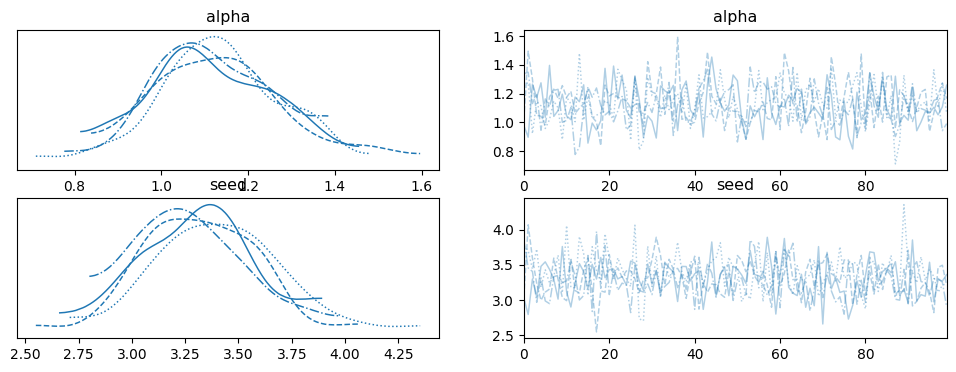

In [ ]:
model.trace_summary()

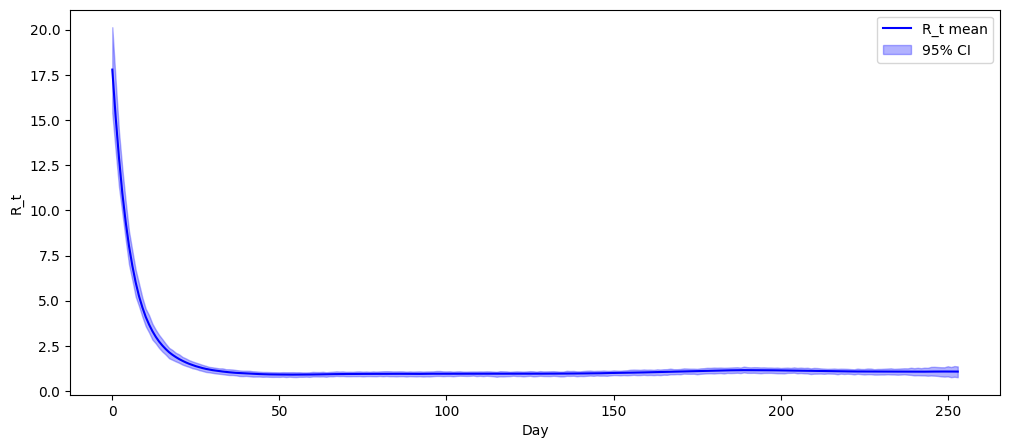

In [ ]:
model.plot_rt()

Output()

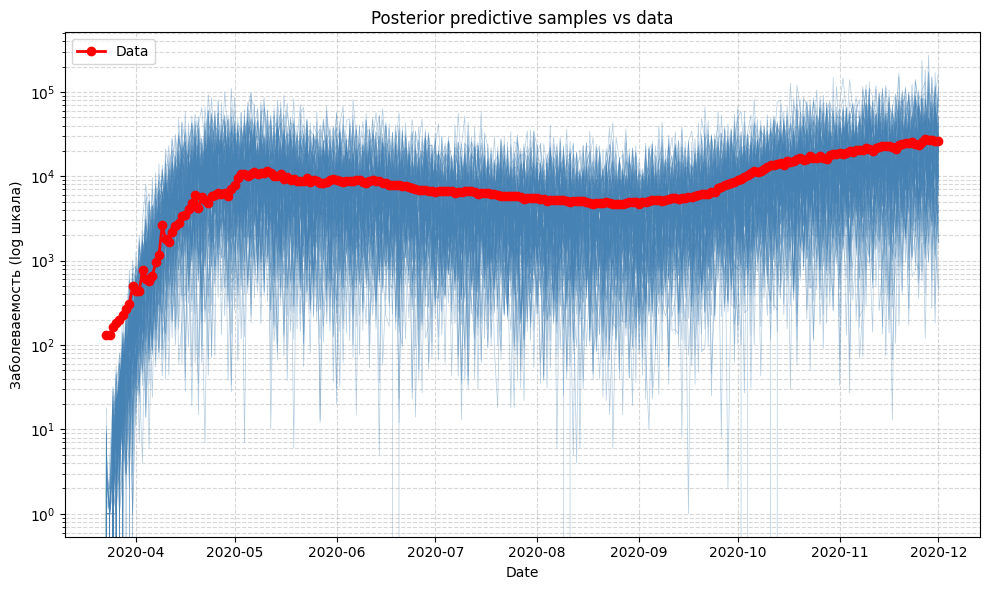

In [ ]:
model.plot_posterior_predictive()

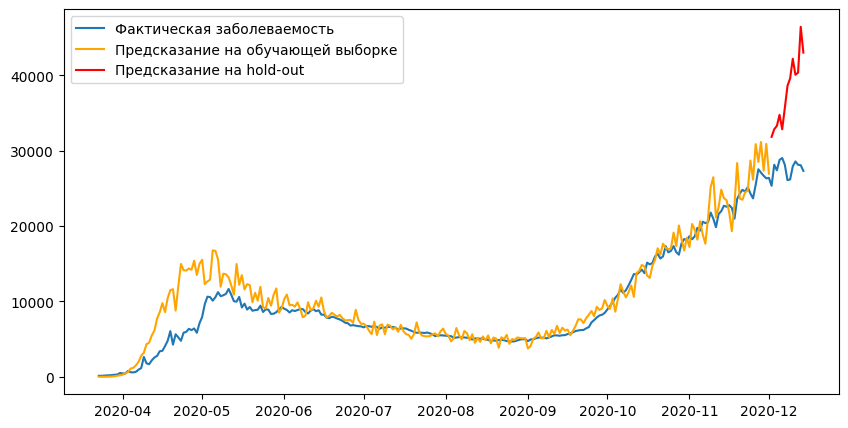

In [ ]:
model.plot_holdout()

In [ ]:
import gc

gc.collect()

148288

In [ ]:
model = CovidModel('Germany')

In [ ]:
model.sample()

Output()

ERROR:pymc.stats.convergence:The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
r_t[0],22.030,1.463,19.359,24.992,0.062,0.065,573.0,332.0,1.02
r_t[1],18.712,1.137,16.635,20.816,0.053,0.045,459.0,312.0,1.01
r_t[2],15.887,0.965,14.259,17.659,0.046,0.040,446.0,304.0,1.02
r_t[3],13.530,0.777,12.128,15.035,0.036,0.034,463.0,341.0,1.01
r_t[4],11.542,0.687,10.220,12.827,0.030,0.030,508.0,370.0,1.00
...,...,...,...,...,...,...,...,...,...
r_t[272],1.079,0.153,0.806,1.381,0.008,0.007,331.0,199.0,1.01
r_t[273],1.079,0.159,0.801,1.394,0.009,0.008,335.0,263.0,1.02
r_t[274],1.079,0.160,0.788,1.382,0.009,0.008,329.0,283.0,1.01
seed,3.503,0.263,3.029,3.999,0.012,0.010,464.0,358.0,1.00


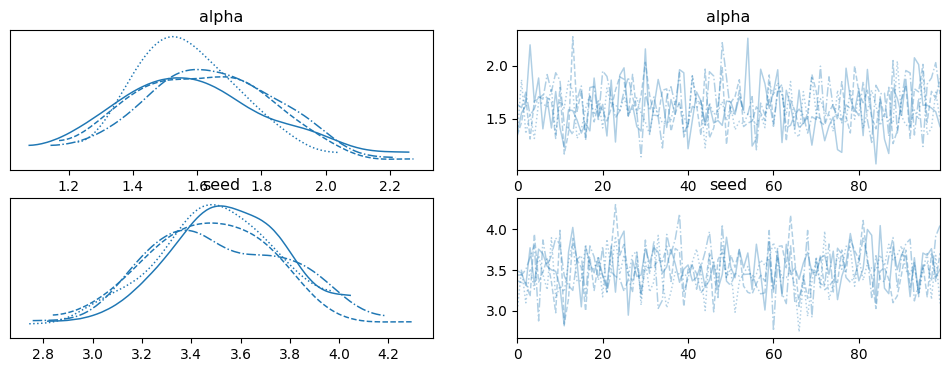

In [ ]:
model.trace_summary()

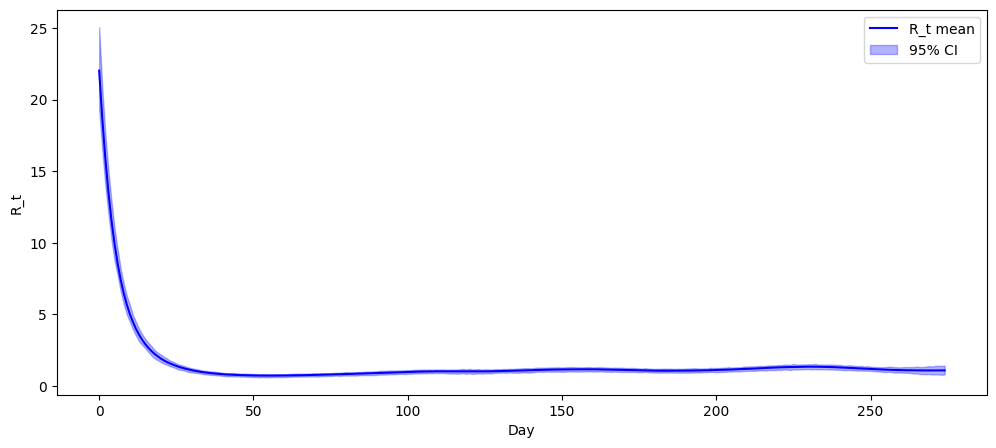

In [ ]:
model.plot_rt()

Output()

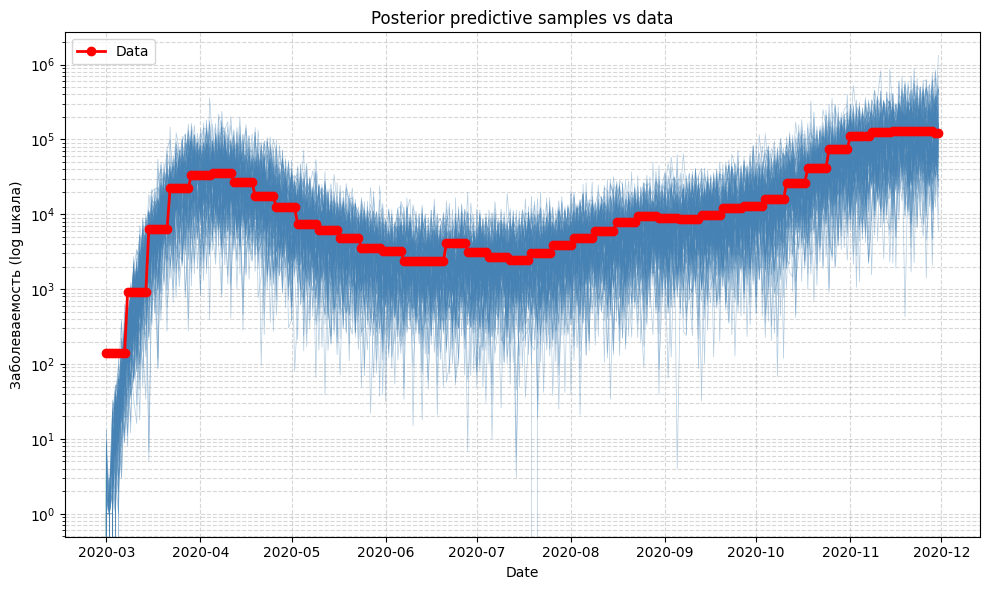

In [ ]:
model.plot_posterior_predictive()

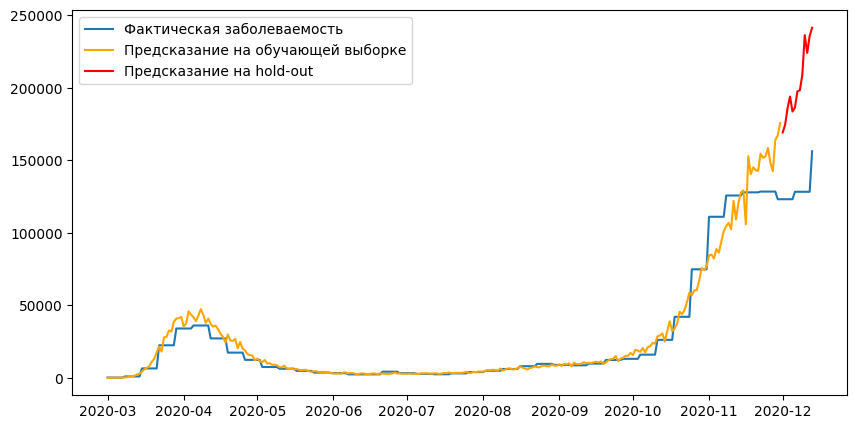

In [ ]:
model.plot_holdout()

In [11]:
model = CovidModel('Italy')

In [12]:
# так как очень долго с большим числом
model.draws = 50
model.tune = 100

In [13]:
model.sample()

Output()

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
r_t[0],22.438,1.669,19.735,26.047,0.098,0.105,296.0,236.0,1.00
r_t[1],18.812,1.398,16.546,21.998,0.077,0.084,328.0,190.0,1.00
r_t[2],15.767,1.109,13.798,17.701,0.066,0.068,282.0,237.0,1.00
r_t[3],13.249,0.970,11.680,15.301,0.057,0.057,289.0,228.0,1.00
r_t[4],11.168,0.750,9.688,12.526,0.045,0.040,275.0,231.0,1.01
...,...,...,...,...,...,...,...,...,...
r_t[275],1.100,0.148,0.859,1.419,0.013,0.009,129.0,137.0,0.99
r_t[276],1.102,0.154,0.831,1.388,0.014,0.009,132.0,136.0,0.99
r_t[277],1.105,0.157,0.841,1.408,0.013,0.010,141.0,192.0,0.99
seed,3.605,0.265,3.152,4.086,0.020,0.015,188.0,168.0,1.02


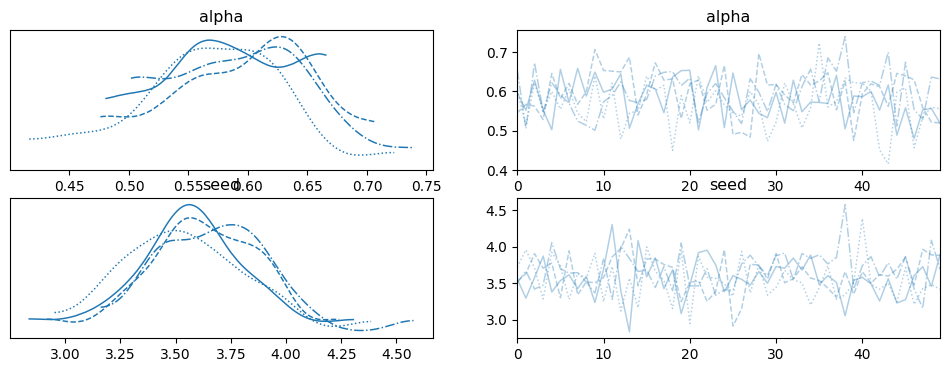

In [14]:
model.trace_summary()

По r_hat и ESS видно, что нужно устанавливать больше сэмплов

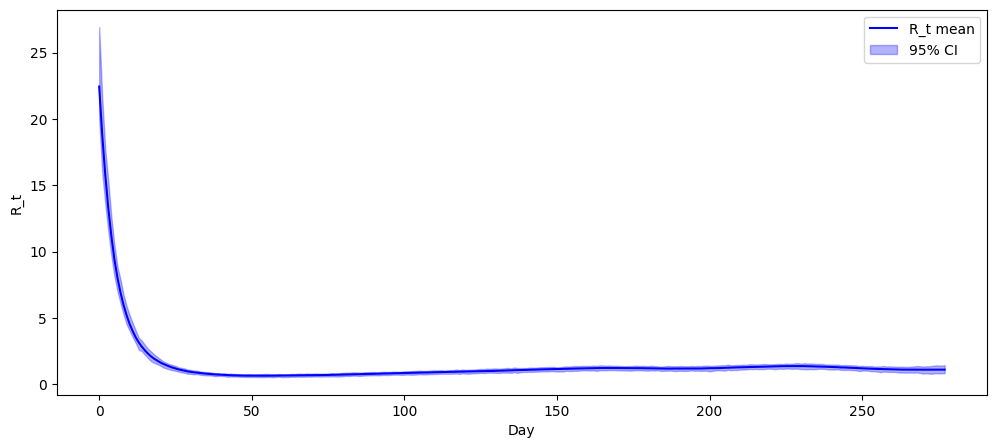

In [15]:
model.plot_rt()

Output()

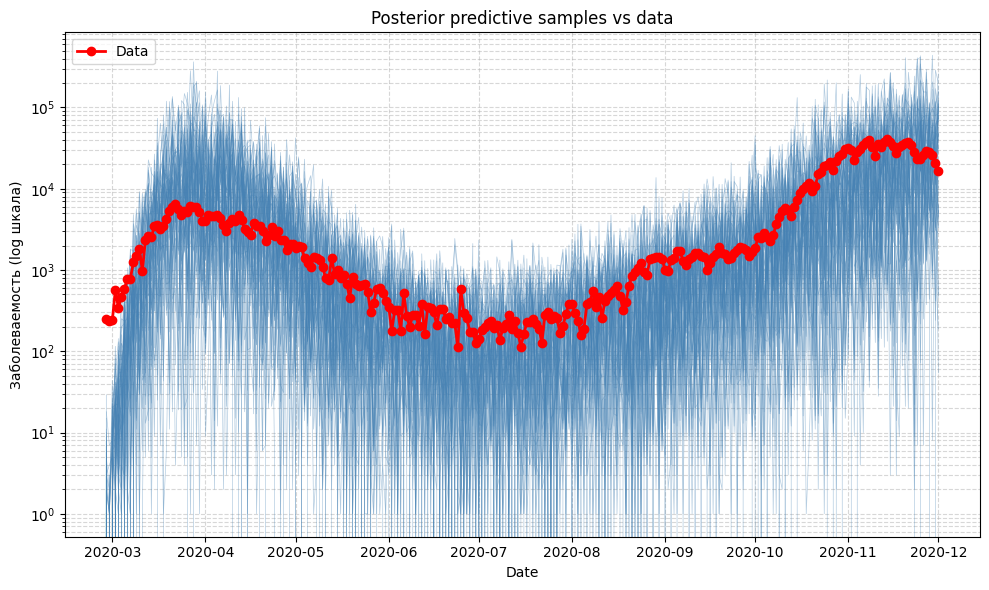

In [16]:
model.plot_posterior_predictive()

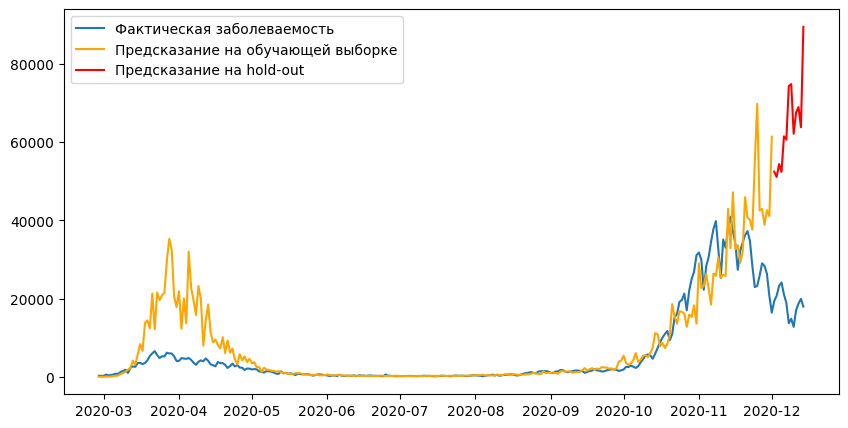

In [29]:
model.plot_holdout()

In [24]:
model.confirmed.shape

(291,)

In [31]:
model = CovidModel('France')

In [32]:
model.draws = 50
model.tune = 100

In [33]:
model.sample()

Output()

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
r_t[0],29.810,2.595,24.861,34.140,0.198,0.128,172.0,242.0,1.00
r_t[1],25.891,2.177,21.487,29.293,0.175,0.093,156.0,160.0,1.01
r_t[2],22.514,1.882,19.339,26.329,0.152,0.081,151.0,241.0,1.01
r_t[3],19.590,1.648,16.674,22.773,0.142,0.078,137.0,161.0,1.01
r_t[4],17.051,1.469,14.811,20.211,0.129,0.090,150.0,186.0,1.01
...,...,...,...,...,...,...,...,...,...
r_t[195],1.144,0.241,0.781,1.669,0.029,0.019,74.0,90.0,1.05
r_t[196],1.141,0.242,0.744,1.591,0.029,0.020,74.0,102.0,1.05
r_t[197],1.141,0.252,0.723,1.668,0.030,0.020,77.0,136.0,1.05
seed,2.847,0.235,2.460,3.266,0.015,0.011,235.0,135.0,0.99


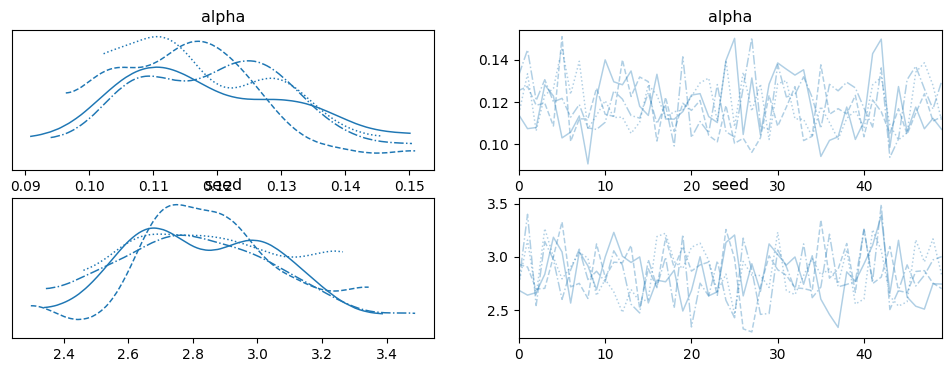

In [34]:
model.trace_summary()

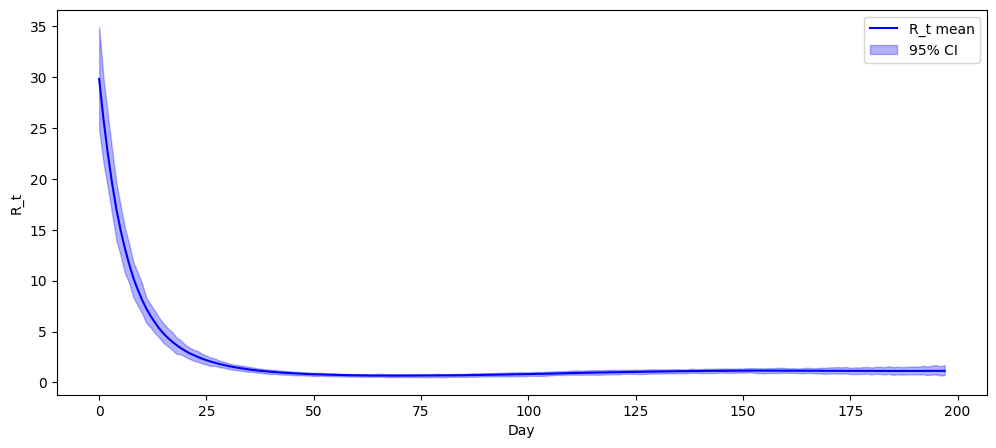

In [35]:
model.plot_rt()

Output()

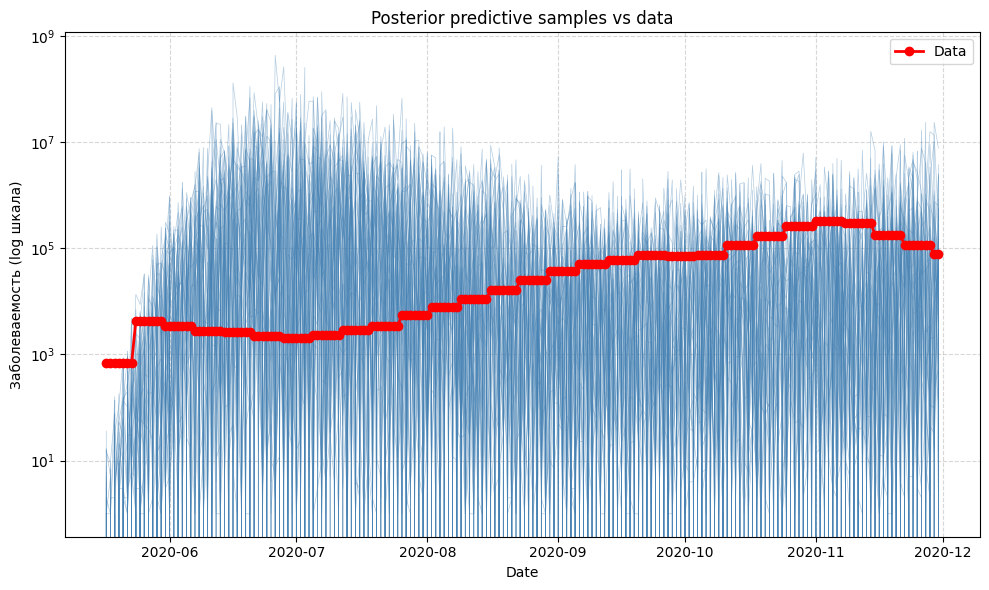

In [36]:
model.plot_posterior_predictive()

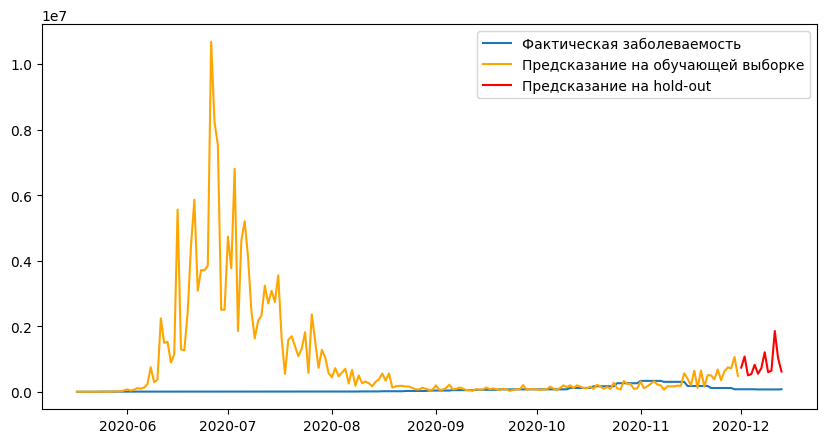

In [37]:
model.plot_holdout()